# Day 05 - Correlation Between Features

Today we want to find out:
- Which features are related to each other?
- Which features are most related to our target (default)?
- Are any two features saying the same thing? (multicollinearity)

Correlation is a number between -1 and 1:
- Close to 1 = both go up together
- Close to -1 = one goes up, other goes down
- Close to 0 = no relationship

## Step 1 - Import and load

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('cs-training-day4-cleaned.csv', index_col=0)

In [21]:
df.shape

(149999, 12)

In [22]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_is_missing
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
5,0,0.907239,49,1,0.024926,23000.0,7,0,1,0,0.0,0


## Step 2 - Calculate correlation of every feature with every other feature

In [23]:
# .corr() calculates correlation between all columns
corr = df.corr()
corr

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_is_missing
SeriousDlqin2yrs,1.000000,0.282988,-0.115397,0.276159,-0.017430,-0.049790,-0.029669,0.291353,-0.007037,0.228411,0.046871,-0.021309
RevolvingUtilizationOfUnsecuredLines,0.282988,1.000000,-0.277241,0.248903,-0.021512,-0.080843,-0.161848,0.241506,-0.070446,0.188588,0.089077,-0.060174
age,-0.115397,-0.277241,1.000000,-0.088137,0.041656,0.084518,0.147700,-0.096611,0.033172,-0.083789,-0.215677,0.136888
NumberOfTime30-59DaysPastDueNotWorse,0.276159,0.248903,-0.088137,1.000000,-0.005948,-0.013144,0.033254,0.479414,0.017344,0.563833,0.048444,-0.025455
DebtRatio,-0.017430,-0.021512,0.041656,-0.005948,1.000000,-0.096018,0.078859,-0.022174,0.184948,-0.015975,-0.090977,0.650410
MonthlyIncome,-0.049790,-0.080843,0.084518,-0.013144,-0.096018,1.000000,0.254237,-0.057334,0.332273,-0.039710,0.186693,-0.096239
NumberOfOpenCreditLinesAndLoans,-0.029669,-0.161848,0.147700,0.033254,0.078859,0.254237,1.000000,-0.117189,0.433963,-0.068261,0.074030,-0.119490
NumberOfTimes90DaysLate,0.291353,0.241506,-0.096611,0.479414,-0.022174,-0.057334,-0.117189,1.000000,-0.073053,0.657662,0.013560,0.014537
NumberRealEstateLoansOrLines,-0.007037,-0.070446,0.033172,0.017344,0.184948,0.332273,0.433963,-0.073053,1.000000,-0.042853,0.129394,-0.064584
NumberOfTime60-89DaysPastDueNotWorse,0.228411,0.188588,-0.083789,0.563833,-0.015975,-0.039710,-0.068261,0.657662,-0.042853,1.000000,0.010867,0.011434


This table is hard to read. Let's make a heatmap - colors make it much easier.

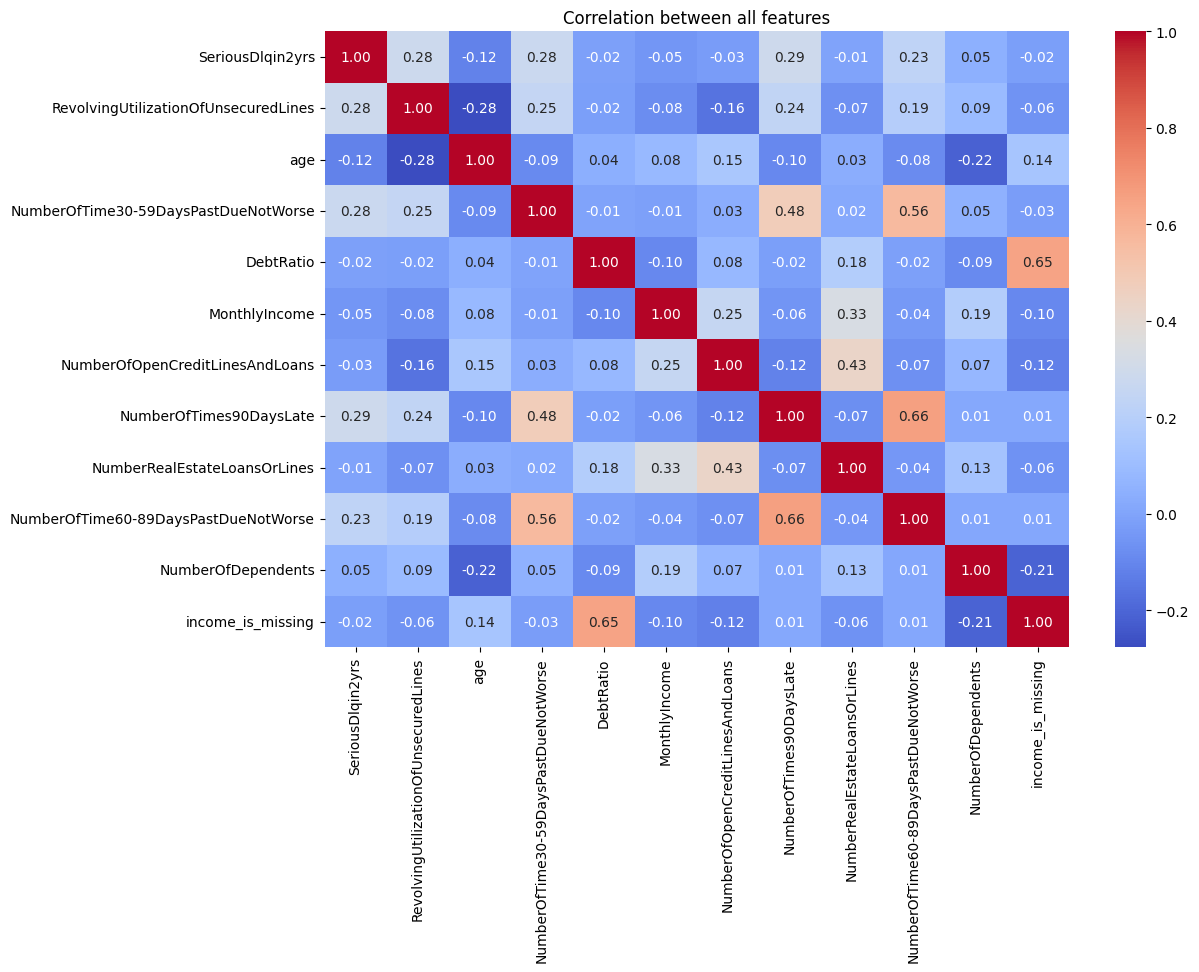

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between all features')
plt.show()

Red = positive correlation, Blue = negative correlation

Look at the row/column called SeriousDlqin2yrs - that shows which features are most related to default

## Step 3 - Which features are most correlated with default?

Let's pull out just the correlation with our target column

In [25]:
# Get correlation of all features with the target
target_corr = corr['SeriousDlqin2yrs']
target_corr

SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.282988
age                                    -0.115397
NumberOfTime30-59DaysPastDueNotWorse    0.276159
DebtRatio                              -0.017430
MonthlyIncome                          -0.049790
NumberOfOpenCreditLinesAndLoans        -0.029669
NumberOfTimes90DaysLate                 0.291353
NumberRealEstateLoansOrLines           -0.007037
NumberOfTime60-89DaysPastDueNotWorse    0.228411
NumberOfDependents                      0.046871
income_is_missing                      -0.021309
Name: SeriousDlqin2yrs, dtype: float64

In [26]:
# Sort from highest to lowest (ignore negative sign, just care about strength)
target_corr = target_corr.abs().sort_values(ascending=False)
target_corr

SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.291353
RevolvingUtilizationOfUnsecuredLines    0.282988
NumberOfTime30-59DaysPastDueNotWorse    0.276159
NumberOfTime60-89DaysPastDueNotWorse    0.228411
age                                     0.115397
MonthlyIncome                           0.049790
NumberOfDependents                      0.046871
NumberOfOpenCreditLinesAndLoans         0.029669
income_is_missing                       0.021309
DebtRatio                               0.017430
NumberRealEstateLoansOrLines            0.007037
Name: SeriousDlqin2yrs, dtype: float64

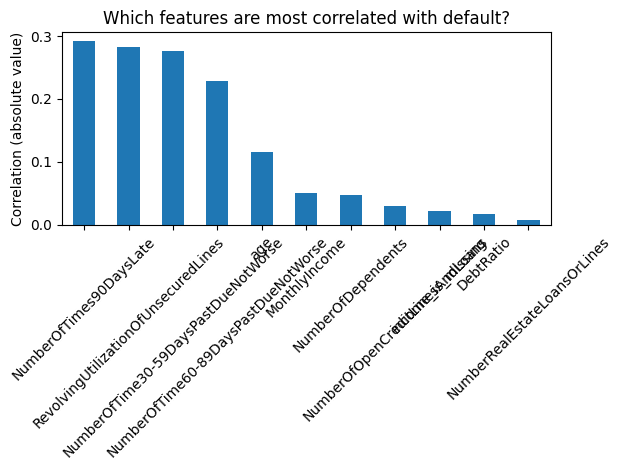

In [27]:
target_corr.drop('SeriousDlqin2yrs').plot(kind='bar')
plt.title('Which features are most correlated with default?')
plt.ylabel('Correlation (absolute value)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Write down - what are the top 3 features most correlated with default?
1. NumberOfTimes90DaysLate 
2. RevolvingUtilizationOfUnsecuredLines    
3. NumberOfTime30-59DaysPastDueNotWorse

## Step 4 - Are any two features highly correlated with each other?

If two features are correlated with each other (not just with target), that can be a problem.
It means they are saying the same thing - one of them might be redundant.

This is called multicollinearity.

In [28]:
# Let's find pairs with correlation above 0.5
# We only look at upper triangle to avoid duplicates

import numpy as np

# Remove the target from this analysis
feature_corr = df.drop(columns=['SeriousDlqin2yrs']).corr()

# Go through each pair
for col in feature_corr.columns:
    for row in feature_corr.index:
        if col != row:
            val = feature_corr.loc[row, col]
            if abs(val) > 0.5 and col < row:  # col < row avoids duplicates
                print(f'{col}  <-->  {row}  :  {round(val, 3)}')

NumberOfTime30-59DaysPastDueNotWorse  <-->  NumberOfTime60-89DaysPastDueNotWorse  :  0.564
DebtRatio  <-->  income_is_missing  :  0.65
NumberOfTime60-89DaysPastDueNotWorse  <-->  NumberOfTimes90DaysLate  :  0.658


These are the features that are highly correlated with each other.

This makes sense - if someone is 90 days late, they were probably also 30 days late first!
So these late payment columns are related to each other.

We will handle this in feature engineering (Day 07).

## Step 5 - Pairplot to visually see relationships

Let's take the top 4 features and plot them against each other.
Color = default or not default.
This shows us visually if the two groups are separable.

In [29]:
# Pick top 4 features + target
top_features = ['NumberOfTimes90DaysLate', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'SeriousDlqin2yrs']

# Use a small sample so it runs fast
sample = df[top_features].sample(2000, random_state=42)

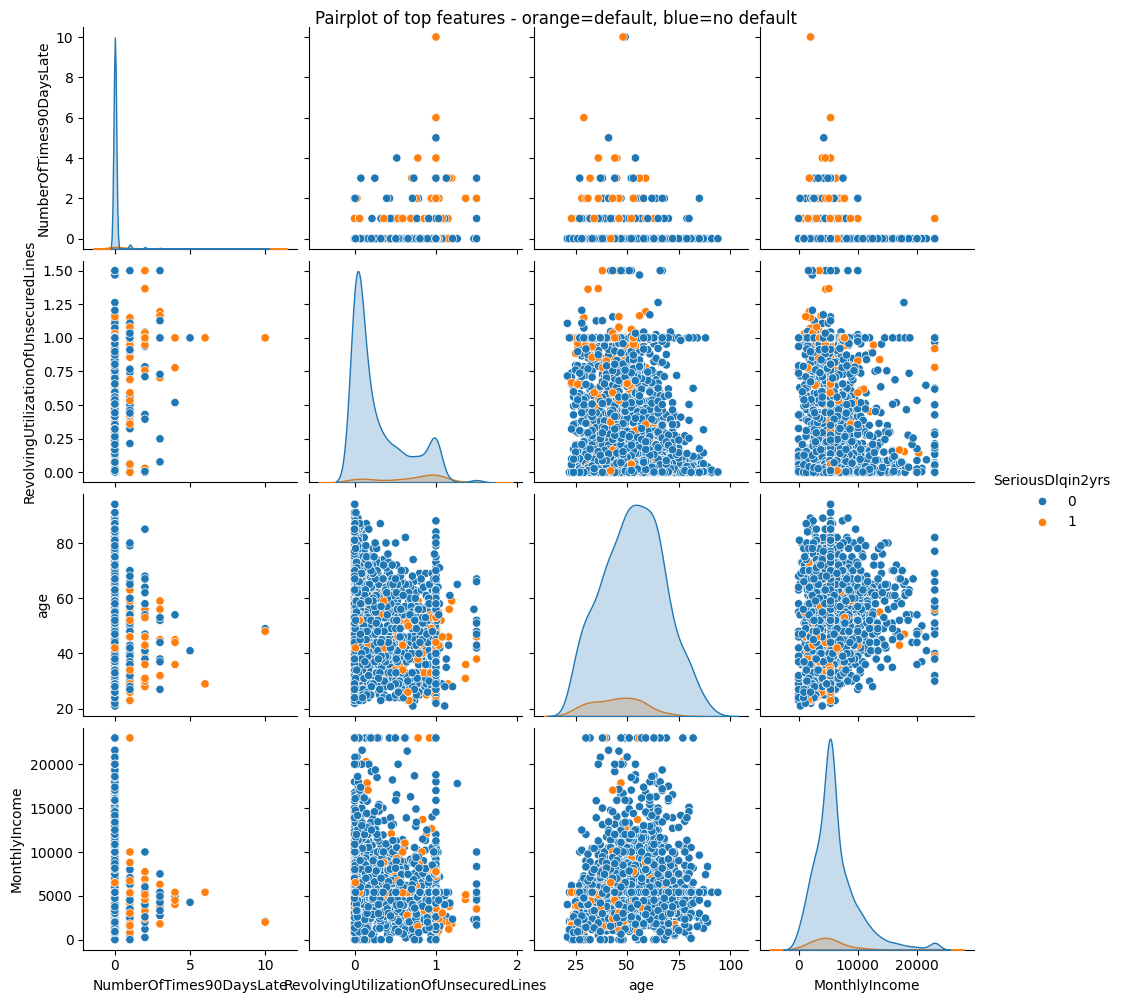

In [37]:
sns.pairplot(sample, hue='SeriousDlqin2yrs')
plt.suptitle('Pairplot of top features - orange=default, blue=no default', y=1.01)
plt.show()

## Step 6 - One more look - scatter plot of two specific features

In [31]:
# Does high utilization + high late payments = default?
defaulters = df[df['SeriousDlqin2yrs'] == 1]
non_defaulters = df[df['SeriousDlqin2yrs'] == 0]

# Sample to avoid overplotting
d_sample = defaulters.sample(500, random_state=42)
nd_sample = non_defaulters.sample(500, random_state=42)

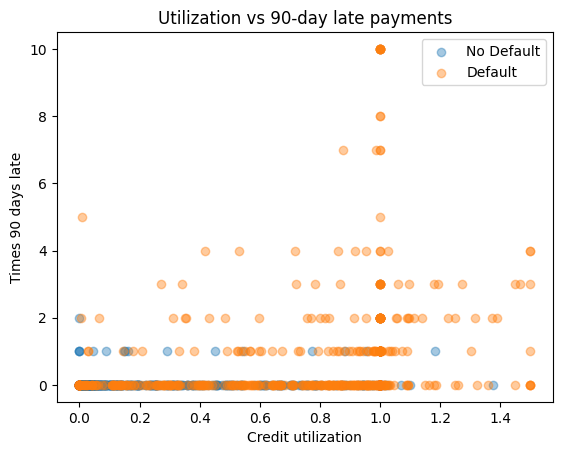

In [41]:
plt.scatter(nd_sample['RevolvingUtilizationOfUnsecuredLines'], nd_sample['NumberOfTimes90DaysLate'], alpha=0.4, label='No Default')
plt.scatter(d_sample['RevolvingUtilizationOfUnsecuredLines'], d_sample['NumberOfTimes90DaysLate'], alpha=0.4, label='Default')
plt.title('Utilization vs 90-day late payments')
plt.xlabel('Credit utilization')
plt.ylabel('Times 90 days late')
plt.legend()
plt.show()

## Step 7 - Save final EDA summary as text

This is your EDA complete. Write a short summary before moving to feature engineering.

In [33]:
print('=== MY EDA SUMMARY ===')
print()
print('Dataset size:', df.shape)
print('Default rate:', round(df['SeriousDlqin2yrs'].mean() * 100, 2), '%')
print()
print('Top features correlated with default:')
print(target_corr.drop('SeriousDlqin2yrs').head(5))
print()
print('Missing values remaining:', df.isnull().sum().sum())

=== MY EDA SUMMARY ===

Dataset size: (149999, 12)
Default rate: 6.68 %

Top features correlated with default:
NumberOfTimes90DaysLate                 0.291353
RevolvingUtilizationOfUnsecuredLines    0.282988
NumberOfTime30-59DaysPastDueNotWorse    0.276159
NumberOfTime60-89DaysPastDueNotWorse    0.228411
age                                     0.115397
Name: SeriousDlqin2yrs, dtype: float64

Missing values remaining: 0


In [34]:
df.to_csv('cs-training-phase1-complete.csv')
print('Phase 1 complete! Data saved.')
print('Next up - Day 06: Feature Engineering')

Phase 1 complete! Data saved.
Next up - Day 06: Feature Engineering


## My observations (fill this yourself)

1. Feature most correlated with default: NumberOfTimes90DaysLate
2. Two features that are correlated with each other: NumberOfTime30-59DaysPastDueNotWorse & NumberOfTime60-89DaysPastDueNotWorse
3. From the pairplot, can you visually separate defaulters from non-defaulters? The classes cannot be perfectly separated visually because there is substantial overlap between defaulters and non-defaulters. However, NumberOfTimes90DaysLate provides the clearest separation, as default cases become more concentrated at higher delinquency counts.
4. One thing I want to explore more: ?

---
Phase 1 EDA is done! Tomorrow we start Feature Engineering.